# Lab: Regression Analysis

### Before you start:

* Read the README.md file
* Comment as much as you can and use the resources (README.md file) 

Happy learning!

## Challenge 1
I work at a coding bootcamp, and I have developed a theory that the younger my students are, the more often they are late to class. In order to test my hypothesis, I have collected some data in the following table:

| StudentID | Age | Tardies |
|--------|-----|------------|
| 1      | 17  | 10         |
| 2      | 51  | 1          |
| 3      | 27  | 5          |
| 4      | 21  | 9         |
| 5      | 36  |  4         |
| 6      | 48  |  2         |
| 7      | 19  |  9         |
| 8      | 26  | 6          |
| 9      | 54  |  0         |
| 10     | 30  |  3         |

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Use this command to create a dataframe with the data provided in the table. 
~~~~
student_data = pd.DataFrame({'Age': [17,51,27,21,36,48,19,26,54,30], 'Tardies': [10,1,5,9,4,2,9,6,0,3]})
~~~~

In [8]:
student_data = {
    'Age': [17,51,27,21,36,48,19,26,54,30], 
    'Tardies': [10,1,5,9,4,2,9,6,0,3]
}

Draw a dispersion diagram (scatter plot) for the data.

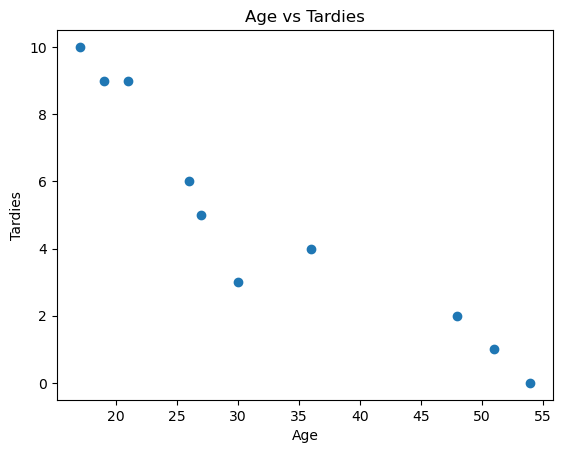

In [ ]:
df = pd.DataFrame(student_data)

plt.scatter(df["Age"], df["Tardies"])    # drawing a dispersion diagram (scatter plot)

plt.xlabel("Age")
plt.ylabel("Tardies")
plt.title("Age vs Tardies")

plt.show()

Do you see a trend? Can you make any hypotheses about the relationship between age and number of tardies?

My Explanation:

- There seems to be a negative relationship between tardiness and age. In particular, the former goes down as the latter increases. Overall, the points in the scatter plot are somewhat close to a straight line, which would indicate a strong relationship between age and tardies. 

- This observation suggests that a linear regression model may be appropriate.

- The hypothesis for now is that tardiness seems to decrease with increasing age in an approximately linear fashion. We will therefore embark in a journey of exploration on whether age influences tardiness.

Calculate the covariance and correlation of the variables in your plot. What is the difference between these two measures? Compare their values. What do they tell you in this case? Add your responses as comments after your code.

In [15]:
covariance_age_tardiness = df["Age"].cov(df["Tardies"])
correlation_age_tardiness = df["Age"].corr(df["Tardies"])
print(covariance_age_tardiness)
print(correlation_age_tardiness)

-45.56666666666666
-0.9391626886887122


In [ ]:
# The covariance is negative, meaning that as one variable increases (age), the other decreases (tardiness).

# The correlation between age and tardiness is close to -1, indicating a strong negative relationship between age and tardiness. This matches the observation in the scatter plot that the points are fairly aligned.

# In other words, the correlation value further confirms the trend observed in the scatter plot, where higher ages are associated with decreasing tardiness.

Build a regression model for this data. What will be your outcome variable? What type of regression are you using? Add your responses as comments after your code.

In [25]:
m, b = np.polyfit(df["Age"], df["Tardies"], 1)   # fitting a degree 1 polynomial (slope m and y-intersect b) into the scatter plot

print("Slope (m):", m)
print("Intercept (b):", b)

Slope (m): -0.2428207709159807
Intercept (b): 12.888803363135764


In [28]:
# Printing the full regression line equation (m and b rounded to 2 decimal places):

print(f"Regression Line: y = {m:.2f}x + {b:.2f}")

Regression Line: y = -0.24x + 12.89


In [29]:
# Creating predicted y values, based on degree 1 polynomial fitting defined in the previous step:

y_prediction = m*df["Age"] + b

Plot your regression model on your scatter plot.

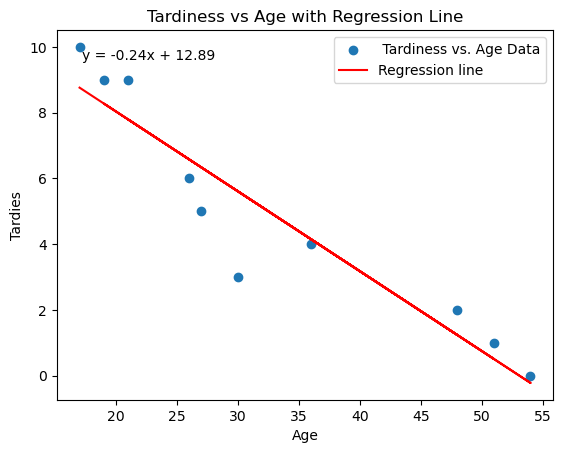

In [ ]:
# Plotting linear regression:

plt.scatter(df["Age"], df["Tardies"], label=" Tardiness vs. Age Data")

plt.plot(df["Age"], y_prediction, color="red", label="Regression line")

plt.xlabel("Age")
plt.ylabel("Tardies")
plt.title("Tardiness vs Age with Regression Line")

plt.text(0.05, 0.95,
         f"y = {m:.2f}x + {b:.2f}",
         transform=plt.gca().transAxes,     # getting current axes (canvas where the plot area is) and changing coordinate system (transaxes)
         verticalalignment='top')

plt.legend()
plt.show()

Interpret the results of your model. What can conclusions can you draw from your model and how confident in these conclusions are you? Can we say that age is a good predictor of tardiness? Add your responses as comments after your code.

My Explanation

 - We built a model (based on the least squares method) that chooses a line such that it minimises the distance between it and all data points in the data frame.  

 - A regression line was therefore added to the scatter plot to model the relationship between age and tardiness. The line has a negative slope, confirming that tardiness decreases with age. The model fits the data closely, indicating that a linear model is appropriate for this relationship.

## Challenge 2
For the second part of this lab, we will use the vehicles.csv data set. You can find a copy of the dataset in the git hub folder. This dataset includes variables related to vehicle characteristics, including the model, make, and energy efficiency standards, as well as each car's CO2 emissions. As discussed in class the goal of this exercise is to predict vehicles' CO2 emissions based on several independent variables. 

In [34]:
# Import any libraries you may need & the data
vehicles = pd.read_csv("../vehicles.csv")

Let's use the following variables for our analysis: Year, Cylinders, Fuel Barrels/Year, Combined MPG, and Fuel Cost/Year. We will use 'CO2 Emission Grams/Mile' as our outcome variable. 

Calculate the correlations between each of these variables and the outcome. Which variable do you think will be the most important in determining CO2 emissions? Which provides the least amount of helpful information for determining CO2 emissions? Add your responses as comments after your code.

In [36]:
vehicles.shape

(35952, 15)

In [37]:
vehicles.head()

,Make,Model,Year,Engine Displacement,Cylinders,Transmission,Drivetrain,Vehicle Class,Fuel Type,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,19.388824,18,17,17,522.764706,1950
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,20.600625,16,17,16,555.437500,2100
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,25.354615,13,13,13,683.615385,2550
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,20.600625,14,21,16,555.437500,2550


In [38]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35952 entries, 0 to 35951
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Make                     35952 non-null  object 
 1   Model                    35952 non-null  object 
 2   Year                     35952 non-null  int64  
 3   Engine Displacement      35952 non-null  float64
 4   Cylinders                35952 non-null  float64
 5   Transmission             35952 non-null  object 
 6   Drivetrain               35952 non-null  object 
 7   Vehicle Class            35952 non-null  object 
 8   Fuel Type                35952 non-null  object 
 9   Fuel Barrels/Year        35952 non-null  float64
 10  City MPG                 35952 non-null  int64  
 11  Highway MPG              35952 non-null  int64  
 12  Combined MPG             35952 non-null  int64  
 13  CO2 Emission Grams/Mile  35952 non-null  float64
 14  Fuel Cost/Year        

In [ ]:
display(vehicles.isnull().sum())     # checking for possible missing values in all columns

display(vehicles.isnull().values.any())    # displaying ANY missing values

display(vehicles.isnull().sum().sum())   # checking total missing entries in the entire dataset via a single figure

display(vehicles.isnull().sum().sum())   # checking rows with potential missing values

Make                       0
Model                      0
Year                       0
Engine Displacement        0
Cylinders                  0
Transmission               0
Drivetrain                 0
Vehicle Class              0
Fuel Type                  0
Fuel Barrels/Year          0
City MPG                   0
Highway MPG                0
Combined MPG               0
CO2 Emission Grams/Mile    0
Fuel Cost/Year             0
dtype: int64

np.False_

np.int64(0)

np.int64(0)

In [ ]:
# No missing values detected.

In [ ]:
# Extracting only numerical columns from the vehicles data set prior to assessing correlations.

vehicles_numeric = vehicles.select_dtypes(include=["number"])
vehicles_numeric

,Year,Engine Displacement,Cylinders,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
0,1984,2.5,4.0,19.388824,18,17,17,522.764706,1950
1,1984,4.2,6.0,25.354615,13,13,13,683.615385,2550
2,1985,2.5,4.0,20.600625,16,17,16,555.437500,2100
3,1985,4.2,6.0,25.354615,13,13,13,683.615385,2550
4,1987,3.8,6.0,20.600625,14,21,16,555.437500,2550
...,...,...,...,...,...,...,...,...,...
35947,2013,1.0,3.0,9.155833,34,38,36,244.000000,1100
35948,2014,1.0,3.0,9.155833,34,38,36,243.000000,1100
35949,2015,1.0,3.0,9.155833,34,38,36,244.000000,1100
35950,2016,0.9,3.0,9.155833,34,39,36,246.000000,1100


In [51]:
vehicles.dtypes

Make                        object
Model                       object
Year                         int64
Engine Displacement        float64
Cylinders                  float64
Transmission                object
Drivetrain                  object
Vehicle Class               object
Fuel Type                   object
Fuel Barrels/Year          float64
City MPG                     int64
Highway MPG                  int64
Combined MPG                 int64
CO2 Emission Grams/Mile    float64
Fuel Cost/Year               int64
dtype: object

In [ ]:
# Checking correlations between all variables in the dataset:

vehicles_numeric.corr()

,Year,Engine Displacement,Cylinders,Fuel Barrels/Year,City MPG,Highway MPG,Combined MPG,CO2 Emission Grams/Mile,Fuel Cost/Year
Year,1.000000,0.037876,0.082469,-0.221084,0.161818,0.267259,0.204751,-0.222300,-0.091913
Engine Displacement,0.037876,1.000000,0.901858,0.789752,-0.740317,-0.715039,-0.746782,0.803520,0.769678
Cylinders,0.082469,0.901858,1.000000,0.739517,-0.703866,-0.650287,-0.698648,0.752393,0.778153
Fuel Barrels/Year,-0.221084,0.789752,0.739517,1.000000,-0.877752,-0.909664,-0.909743,0.986189,0.916208
City MPG,0.161818,-0.740317,-0.703866,-0.877752,1.000000,0.923856,0.985457,-0.894139,-0.858645
Highway MPG,0.267259,-0.715039,-0.650287,-0.909664,0.923856,1.000000,0.969392,-0.926405,-0.851404
Combined MPG,0.204751,-0.746782,-0.698648,-0.909743,0.985457,0.969392,1.000000,-0.926229,-0.875185
CO2 Emission Grams/Mile,-0.222300,0.803520,0.752393,0.986189,-0.894139,-0.926405,-0.926229,1.000000,0.930865
Fuel Cost/Year,-0.091913,0.769678,0.778153,0.916208,-0.858645,-0.851404,-0.875185,0.930865,1.000000


In [ ]:
# Checking correlations between the specified variables of interest for this challenge.

# Correlation matrix:

vehicles[["Year", "Cylinders", "Fuel Barrels/Year", "Combined MPG", "Fuel Cost/Year", "CO2 Emission Grams/Mile"]].corr()

,Year,Cylinders,Fuel Barrels/Year,Combined MPG,Fuel Cost/Year,CO2 Emission Grams/Mile
Year,1.000000,0.082469,-0.221084,0.204751,-0.091913,-0.222300
Cylinders,0.082469,1.000000,0.739517,-0.698648,0.778153,0.752393
Fuel Barrels/Year,-0.221084,0.739517,1.000000,-0.909743,0.916208,0.986189
Combined MPG,0.204751,-0.698648,-0.909743,1.000000,-0.875185,-0.926229
Fuel Cost/Year,-0.091913,0.778153,0.916208,-0.875185,1.000000,0.930865
CO2 Emission Grams/Mile,-0.222300,0.752393,0.986189,-0.926229,0.930865,1.000000


In [ ]:
# Ranking correlations between all numerical columns, namely all numercial variables vs CO2 Emission Grams/Mile 

vehicles.select_dtypes(include=["number"]).corr()["CO2 Emission Grams/Mile"].sort_values()

Highway MPG               -0.926405
Combined MPG              -0.926229
City MPG                  -0.894139
Year                      -0.222300
Cylinders                  0.752393
Engine Displacement        0.803520
Fuel Cost/Year             0.930865
Fuel Barrels/Year          0.986189
CO2 Emission Grams/Mile    1.000000
Name: CO2 Emission Grams/Mile, dtype: float64

In [54]:
features = ["Year", "Cylinders", "Fuel Barrels/Year", "Combined MPG", "Fuel Cost/Year"]
target = "CO2 Emission Grams/Mile"

In [57]:
# Building a correlation matrix, based on the specified features and target for this challenge:

corr = vehicles[features + [target]].corr()[target]

In [58]:
# Sorting and printing correlations computed via correlation matrix for this challenge:

corr_sorted = corr.sort_values(ascending=False)
print(corr_sorted)

CO2 Emission Grams/Mile    1.000000
Fuel Barrels/Year          0.986189
Fuel Cost/Year             0.930865
Cylinders                  0.752393
Year                      -0.222300
Combined MPG              -0.926229
Name: CO2 Emission Grams/Mile, dtype: float64


In [59]:
corr_abs = vehicles[features + [target]].corr()[target].drop(target).abs().sort_values(ascending=False)
print(corr_abs)

Fuel Barrels/Year    0.986189
Fuel Cost/Year       0.930865
Combined MPG         0.926229
Cylinders            0.752393
Year                 0.222300
Name: CO2 Emission Grams/Mile, dtype: float64


In [60]:
corr_vehicles = pd.DataFrame({
    "correlation": corr,
    "abs_correlation": corr.abs()
}).sort_values(by="abs_correlation", ascending=False)

print(corr_vehicles)

                         correlation  abs_correlation
CO2 Emission Grams/Mile     1.000000         1.000000
Fuel Barrels/Year           0.986189         0.986189
Fuel Cost/Year              0.930865         0.930865
Combined MPG               -0.926229         0.926229
Cylinders                   0.752393         0.752393
Year                       -0.222300         0.222300


My Response:

- The most important variable in determining CO2 emissions is the one with the highest absolute correlation value (Fuel Barrels/Year; |corr| ~ 0.99). A strong negative correlation is just as important as a strong positive one; it simply indicates an inverse relationship rather than a direct one. Also worthy of note, therefore, are the variables pertaining to Fuel Cost/Year and Combined MPG (|corr| ~ 0.93, respectively). The least useful variable is the one whose correlation is closest to zero, indicating little to no linear relationship with the outcome. That is the Year variable.

Build a regression model for this data. What type of regression are you using? Add your responses as comments after your code.

In [ ]:
# Your code here.

Print your regression summary, and interpret the results. What are the most important varibles in your model and why? What can conclusions can you draw from your model and how confident in these conclusions are you? Add your responses as comments after your code.

In [ ]:
# Your code here.

## Bonus Challenge: Error Analysis

I am suspicious about the last few parties I have thrown: it seems that the more people I invite the more people are unable to attend. To know if my hunch is supported by data, I have decided to do an analysis. I have collected my data in the table below, where X is the number of people I invited, and Y is the number of people who attended. 

|  X |  Y |
|----|----|
| 1  |  1 |
| 3  |  2 |
| 4  |  4 |
| 6  |  4 |
| 8  |  5 |
| 9  |  7 |
| 11 |  8 |
| 14 |  13 |

We want to know if the relationship modeled by the two random variables is linear or not, and therefore if it is appropriate to model it with a linear regression. 
First, build a dataframe with the data. 

In [ ]:
# Your code here.

Draw a dispersion diagram (scatter plot) for the data, and fit a regression line.

In [ ]:
# Your code here.

What do you see? What does this plot tell you about the likely relationship between the variables? Print the results from your regression.

*your explanation here*

Do you see any problematic points, or outliers, in your data? Remove these points and recalculate your regression. Print the new dispersion diagram with your new model and the results of your model. 

In [ ]:
# Your response here.

What changed? Based on the results of the two models and your graphs, what can you say about the form of the data with the problematic point and without it?

*your explanation here*